In [1]:
pip install tensorflow

  Using cached tensorflow-2.21.0-cp311-cp311-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached h5py-3.14.0-cp311-cp311-win_amd64.whl.metadata (2.7 kB)
  Using cached ml_dtypes-0.5.4-cp311-cp311-win_amd64.whl.metadata (9.2 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached optree-0.19.1-cp311-cp311-win_amd64.whl.metadata (32 kB)
  Using cached markdown_it_

In [2]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [3]:
import pandas as pd

train_df = pd.read_csv("../data/train_clean.csv")
test_df = pd.read_csv("../data/test_clean.csv")

In [4]:
full_df = pd.concat(
    [train_df, test_df],
    ignore_index=True
)

print(full_df.shape)

(985, 5)


In [5]:
from sklearn.model_selection import train_test_split

X = full_df["clean_poem"]
y = full_df["Genre"]

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train_text)
y_test = le.transform(y_test_text)

print(le.classes_)

['Affection' 'Death' 'Environment' 'Music']


In [7]:
lengths = [len(text.split()) for text in X_train_text]

print("Mean:", sum(lengths)/len(lengths))
print("Max:", max(lengths))

Mean: 25.772842639593907
Max: 47


In [8]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 10000

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train_text)

In [9]:
X_train = tokenizer.texts_to_sequences(X_train_text)
X_test = tokenizer.texts_to_sequences(X_test_text)

In [10]:
MAX_LEN = 50

X_train = pad_sequences(
    X_train,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    X_test,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print(X_train.shape)
print(X_test.shape)

(788, 50)
(197, 50)


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

In [12]:
lstm_model = Sequential([

    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128,
        input_length=MAX_LEN
    ),

    LSTM(64),

    Dense(32, activation="relu"),

    Dense(4, activation="softmax")
])

d:\conda_envs\poem_nlp\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [13]:
lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [15]:
history = lstm_model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6651 - loss: 0.7172 - val_accuracy: 0.3165 - val_loss: 2.1808
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6556 - loss: 0.7611 - val_accuracy: 0.2911 - val_loss: 1.9204
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6905 - loss: 0.6404 - val_accuracy: 0.3165 - val_loss: 2.1580
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.6683 - loss: 0.6597 - val_accuracy: 0.3481 - val_loss: 2.2620
Epoch 5/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6667 - loss: 0.7100 - val_accuracy: 0.3291 - val_loss: 2.0499
Epoch 6/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6714 - loss: 0.7359 - val_accuracy: 0.3038 - val_loss: 2.0748
Epoch 7/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6810 - loss: 0.6949 - val_accuracy: 0.3418 - val_loss: 1.8218
Epoch 8/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6984 - loss: 0.6567 - val_accuracy: 0.3354 - v

In [17]:
loss, acc = lstm_model.evaluate(
    X_test,
    y_test
)

print("LSTM Accuracy:", acc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2437 - loss: 2.1474 
LSTM Accuracy: 0.24365481734275818


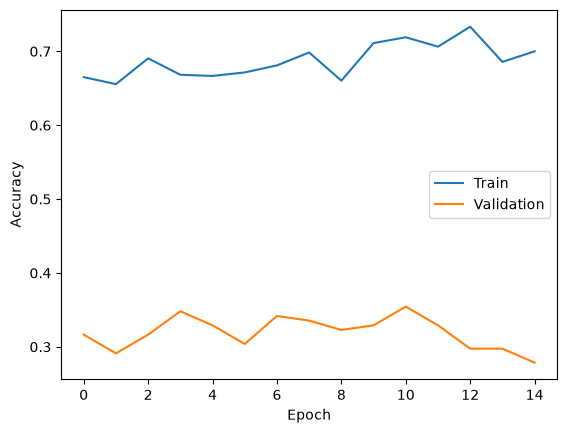

In [18]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

In [19]:
print(full_df["Genre"].value_counts())

Genre
Environment    252
Music          250
Death          242
Affection      241
Name: count, dtype: int64


In [20]:
print(y_train_text.value_counts())
print()
print(y_test_text.value_counts())

Genre
Environment    202
Music          200
Death          193
Affection      193
Name: count, dtype: int64

Genre
Music          50
Environment    50
Death          49
Affection      48
Name: count, dtype: int64


In [21]:
print(X_train.shape)
print(X_test.shape)

(788, 50)
(197, 50)


In [22]:
print(X_train[:3])

[[2549 1380 2550 2551 2552  747   33 2553  298  621 2554 2555  299   62
    62    3 2556 2557  519 2558  748  749 2559  750 1381  982 2560  751
   149   90    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 983 2561  520  190 2562 2563 2564 2565 2566 1382 2567 2568   56  984
    14  985  382 2569 2570    6 2571 2572   97   67  622 2573 2574 2575
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1383 2576  127 2577 2578   36  336 2579 2580  986 2581 1384  752 1384
   987 2582  521   38 2583   81  112  988 1385   19 2584  150 2585 2586
  1386   28   98 2587  522 1387    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]]


In [23]:
print(history.history["accuracy"])
print(history.history["val_accuracy"])

[0.6650793552398682, 0.6555555462837219, 0.6904761791229248, 0.6682539582252502, 0.6666666865348816, 0.6714285612106323, 0.6809523701667786, 0.6984127163887024, 0.6603174805641174, 0.7111111283302307, 0.7190476059913635, 0.7063491940498352, 0.7333333492279053, 0.6857143044471741, 0.699999988079071]
[0.3164556920528412, 0.29113924503326416, 0.3164556920528412, 0.34810125827789307, 0.3291139304637909, 0.3037974536418915, 0.3417721390724182, 0.33544304966926575, 0.32278481125831604, 0.3291139304637909, 0.3544303774833679, 0.3291139304637909, 0.297468364238739, 0.297468364238739, 0.27848100662231445]


In [24]:
import numpy as np

best_epoch = np.argmax(history.history["val_accuracy"])

print("Best Epoch:", best_epoch + 1)
print("Best Val Accuracy:", max(history.history["val_accuracy"]))

Best Epoch: 11
Best Val Accuracy: 0.3544303774833679


In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

model = Sequential([

    Embedding(
        input_dim=10000,
        output_dim=64,
        input_length=50
    ),

    Bidirectional(
        LSTM(
            32,
            dropout=0.3,
            recurrent_dropout=0.3
        )
    ),

    Dense(
        16,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        4,
        activation="softmax"
    )
])

In [27]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [28]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True
)

In [29]:
history_bilstm = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.2667 - loss: 1.3895 - val_accuracy: 0.2215 - val_loss: 1.3880
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.3254 - loss: 1.3765 - val_accuracy: 0.2152 - val_loss: 1.3860
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.3968 - loss: 1.3522 - val_accuracy: 0.2215 - val_loss: 1.3822
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.4492 - loss: 1.2458 - val_accuracy: 0.2785 - val_loss: 1.3489
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.5603 - loss: 1.0487 - val_accuracy: 0.2595 - val_loss: 1.3832
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.6508 - loss: 0.8622 - val_accuracy: 0.2468 - val_loss: 1.5162
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.7492 - loss: 0.7190 - val_accuracy: 0.3481 - val_loss: 1.5245
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.8254 - loss: 0.5773 - val_accuracy: 0.3291 -

In [31]:
loss, acc = model.evaluate(
    X_test,
    y_test
)

print("BiLSTM Accuracy:", acc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2589 - loss: 2.0634
BiLSTM Accuracy: 0.2588832378387451


In [32]:
import numpy as np

best_epoch = np.argmax(
    history_bilstm.history["val_accuracy"]
)

print("Best Epoch:", best_epoch + 1)

print(
    "Best Val Accuracy:",
    max(history_bilstm.history["val_accuracy"])
)

Best Epoch: 10
Best Val Accuracy: 0.3734177350997925


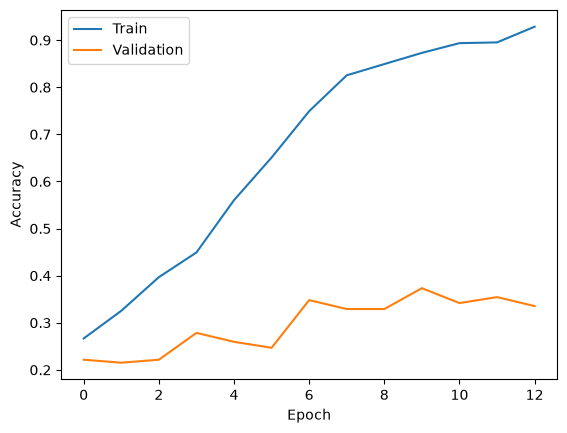

In [33]:
import matplotlib.pyplot as plt

plt.plot(history_bilstm.history["accuracy"])
plt.plot(history_bilstm.history["val_accuracy"])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Train",
    "Validation"
])

plt.show()